# Visualisation of Pareto Fronts, System Functionality and Water Loss for the Multi-Objective Optimisation of the Number of Repair Crews in the BPDRR

This notebook generates the visual representations (Pareto fronts and time series) of the results produced by the `MOO_BPDRR_NRC.ipynb` notebook.

The optimisation results are provided as two CSV files:

- **`pareto_OF_x.csv`**: contains the values of the objective functions for each solution obtained from the multi-objective optimisation process.
- **`pareto_solutions_x.csv`**: contains the repair order of the damaged pipes associated with each solution obtained from the multi-objective optimisation process.

This notebook requires three Python files specific to this research, which are used as modules:

- **`OF_BPDRR.py`**: Contains the functions used to calculate the objective functions from the BPDRR.
- **`RC_scheduling.py`**: Contains the functions used to estimate the allocation and scheduling of the repair crews.
- **`visuals_BPDRR.py`**: Contains the functions used to generate the Pareto fronts and time-series plots.

Please make sure that these modules are available in the appropriate directory and are imported correctly before running the notebook.

In [124]:
# Import libraries to be used
import os
import wntr
import pandas as pd
import numpy as np

# Specialized libraries for this project
import OF_BPDRR as OF
import RC_scheduling as rcs
import visuals_BPDRR as visuals

### Selection of the scenario, specific solution, and number of crews

The cell below allows the user to select the following:

- **`ds_sel`**: Select one of the five damage scenarios to analyse (`DS1`, `DS2`, `DS3`, `DS4`, or `DS5`).
- **`n_crews`**: Specify the number of repair crews used in the optimisation process. This variable is used for labelling the plots.
- **`gen_sel`**: Select the generation to which the solution being plotted belongs.
- **`sol_sel`**: Select one of the solutions obtained from the multi-objective optimisation process. This is required to generate the functionality and water-loss time series.


In [125]:
# which damage scenario to analyse
ds_sel = 'DS2'  # Replace with the desired damage scenario (DS1, DS2, DS3, DS4, DS5)

# Number of crews available for the restoration simulation
n_crews = 30

# Generation to which the selected solution belongs
gen_sel = 15

# Select the solution to plot (0 to the number of solutions in the selected generation)
sol_sel = 2  # Replace with the index of the desired solution



In [126]:
# Dictionary to store information for the plot title
plot_info = {
    "scenario": ds_sel,
    "solution": sol_sel,
    "generation": gen_sel,
    "crews": n_crews
}

In [127]:
# load the wdn as INP file WITH the broken pipes
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"

# Define the temporary INP file used for the restoration simulation
temp_inp="temp_restoration_"+ds_sel+".inp"

# Load the water network model from the INP file
wn = wntr.network.WaterNetworkModel(inp_file)

In [128]:
# Simulation settings
wn.options.time.duration = 15 * 24 * 3600       # Time duration of the WNTR simulation
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [129]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [130]:
# Read the data from the excel file that contains the repair times for the selected damage scenario
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")

106 repairs loaded.


In [131]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [132]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

In [133]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)


In [134]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

In [135]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Standardise IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)


In [136]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {

    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,
    
}

In [137]:
# Read the data from the CSV file containing the objective function values for the selected damage scenario MOO
data = pd.read_csv(
    f"pareto_OF_history_{ds_sel}_{n_crews}RC.csv",
    index_col=["Generation", "Solution"]
)

data[-126:]

FH     t95           RL        TNS  NWSECH            WL
Generation Solution                                                           
15         0         0.0   180.0  3169.462842   9.008569     3.0  10652.219727
           1         0.0   180.0  3169.747624   9.012140     3.0  10640.534180
           2         0.0  1140.0  3468.867818   9.333492     1.0   8557.436523
           3         0.0   180.0  3171.547264   8.787194     1.0  10740.205078
           4         0.0   180.0  2821.198126   9.426327     4.0  10217.362305
...                  ...     ...          ...        ...     ...           ...
           121       0.0  1140.0  3516.960627   9.319210     2.0   9700.339844
           122       0.0  1140.0  3486.294368   9.390621     3.0   9406.723633
           123       0.0  1140.0  3558.399551   9.304927     2.0   9361.549805
           124       0.0   180.0  2978.200794  11.011664     9.0   9132.488281
           125       0.0  1140.0  3579.557115   9.551297     2.0   9248.572266

[126 rows x 6 columns]

In [138]:
# Read the data from the CSV file containing the repair orders
pareto_solutions = pd.read_csv(
    f"pareto_solutions_history_{ds_sel}_{n_crews}RC.csv",
    index_col=["Generation", "Solution"]
)

pareto_solutions

0    1   2    3   4    5   6   7   8    9  ...   96  \
Generation Solution                                              ...        
1          0         78   58  61  103  91   55  69   2  45   48  ...   17   
           1         85   71  59   64  53   97  79  44  63    1  ...   27   
           2         68   58  32   44  81  104  67  13  69   15  ...   20   
           3         38   70  51   84  24   36  58  99   7  105  ...  103   
           4         60    3   6   63   2   93  43  67   4   64  ...   82   
...                  ..  ...  ..  ...  ..  ...  ..  ..  ..  ...  ...  ...   
15         121       79  102  40   68  30   26  25  23  78    3  ...   57   
           122       92   23   3  100  10   94   9  57  13   88  ...   60   
           123       92   82  45   33  95   22  29  20  23   34  ...   99   
           124       92   48  23   47  25    5  51   4  28   12  ...   96   
           125       23   16  22   29   3   37  25   1  72   17  ...   92   

                      97  98  99  100  101  102  103  104  105  
Generation Solution                                             
1          0          64  84  72   93    8   75   35   30   39  
           1          38  49  40   18   95   82   69    6   19  
           2          76  79  38   66   35   75   63   23   30  
           3          45  68  35   21   49    6  101   72   92  
           4          27  84  99   19  101   29   28   69   54  
...                  ...  ..  ..  ...  ...  ...  ...  ...  ...  
15         121        72  95  36   87  104   21   59   50   98  
           122        33  85  29   14   47   81   48   70   56  
           123       105  35  63   93  103   85   16   14   73  
           124        33  93  56   81   27   45   70   52   14  
           125        99  41  90   69   89   73   47   91   63  

[1890 rows x 106 columns]

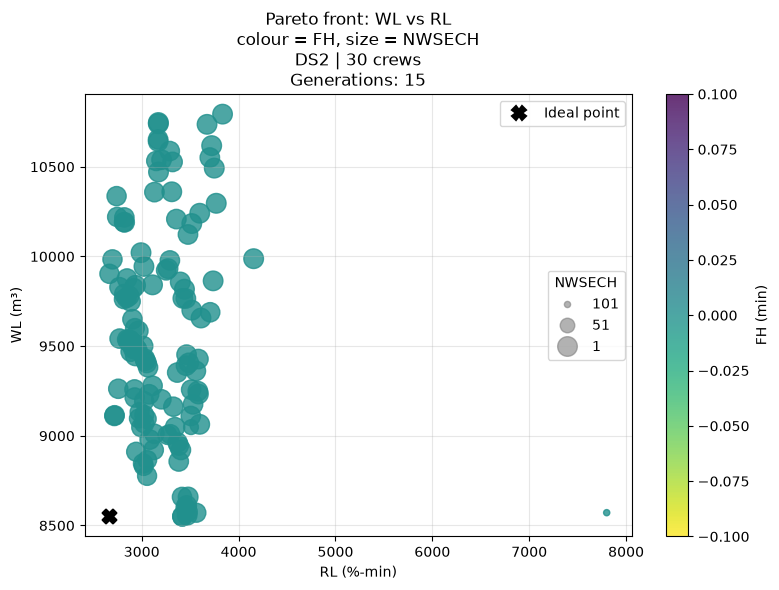

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL\ncolour = FH, size = NWSECH\nDS2 | 30 crews\nGenerations: 15'}, xlabel='RL (%-min)', ylabel='WL (m³)'>)

In [139]:
# Pareto front plot using four objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
# Generations: Choose the generations to plot e.g. last three gennerations= [48, 49, 50])
obj1="RL"
obj2="WL"

visuals.plot_pareto_OF_MG(
    data=data,
    obj1=obj1,
    obj2=obj2,
    color_obj="FH",
    size_obj="NWSECH",
    plot_info=plot_info,
    generations=[15]
)

In [147]:
# Filter Pareto solutions by objective-function ranges
pareto_generation = data.loc[gen_sel].copy()

# Define the objective-function ranges (edit according to your selected objectives and the solutions you want to find)
obj1_min = 3200  
obj1_max = 3800

obj2_min = 8500
obj2_max = 8700

# Filter the Pareto front
selected_solutions = pareto_generation[
    pareto_generation[obj1].between(obj1_min, obj1_max)
    &
    pareto_generation[obj2].between(obj2_min, obj2_max)
]

# Display the selected solutions
print(
    f"Found {len(selected_solutions)}"
    f" solutions within the specified ranges:"
)

selected_solutions

Found 9 solutions within the specified ranges:


,FH,t95,RL,TNS,NWSECH,WL
Solution,,,,,,
2,0.0,1140.0,3468.867818,9.333492,1.0,8557.436523
10,0.0,1140.0,3415.894621,10.047608,5.0,8659.107422
11,0.0,1140.0,3464.052888,9.226375,1.0,8611.400391
12,0.0,1140.0,3419.378840,10.029755,5.0,8550.773438
33,0.0,1140.0,3419.378840,10.029755,5.0,8550.773438
64,0.0,1140.0,3479.415462,9.226375,1.0,8658.763672
65,0.0,1140.0,3453.154684,10.033325,6.0,8598.757812
79,0.0,1140.0,3564.121130,10.458224,8.0,8570.992188
88,0.0,1140.0,3473.348026,9.633421,3.0,8576.268555


### Time Series Section

This section of the notebook is used to generate the functionality and water-loss time series for the selected solution.

Because these time series require the hydraulic results for each timestep throughout the simulation period, it is necessary to run a restoration simulation using the repair order associated with the selected solution. The simulation results are then used to calculate the functionality and water-loss time series, as well as the corresponding objective values, such as the time to 95% recovery (t95), resilience loss (RL), and water loss (WL).

In [141]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the simulation.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule

    schedule = rcs.create_schedule(

        reparations=scenario["reparations"],

        dmatrix=scenario["dmatrix"],

        pipe_ids=scenario["pipe_ids"],

        indexes=indexes,

        n_crews=scenario["n_crews"],

    )

    # Generate EPANET controls

    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP

    rcs.write_inp_controls(

        input_inp=scenario["damaged_inp"],

        output_inp=scenario["temp_inp"],

        schedule=schedule,

        new_controls=controls,

    )

    # Load temporary network

    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation
    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP

    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation

    simulation = {

        "results": results,

        "schedule": schedule,

        "network": wn,

    }

    return simulation

In [142]:
# Order of the pipe's indexes from the selected solution 
indexes = pareto_solutions.loc[
    (gen_sel, sol_sel)
].to_numpy(dtype=int)

#print("Generation:", gen_sel)
print("Solution:", sol_sel)
print("Indexes:")
print(indexes)

Solution: 2
Indexes:
[ 36  23  16  22  29   3 100  10  94   9  57  60  13  78  88  25   7  65  58   1  72  17 103   2  51  21  41   4  34  26  28  37  40  50   6  30  64  79  86  90  80  67  87  77  12  69  32  59  84  11  99  46  97  76  95  55  83  96 105 104   0 101  18  43  19  27  31   5  61  71  42  33   8  68
  20  49  15  39  38  24 102  74  44  35  53  85  89  62  52  93  91  54  66  63  48  75  45  82  70  73  98  47  14  56  81  92]


In [143]:
# Run one restoration simulation
simulation = simulate_restoration(
    indexes=indexes,
    scenario=scenario,
#    temp_inp=temp_inp,
    save_temp_inp=False
)

# Extract simulation results
results = simulation["results"]

demand = results.node["demand"] * 1000  # convert to L/s

pressure = results.node["pressure"]

flowrate = results.link["flowrate"]


# Supply ratio
supply_ratio = (
    demand[scenario["demand_nodes"]]
    / scenario["expected"]
)

# Objective 1 - Time without supply for hospital/firefighting (FH)
FH, FH_undersupplied = OF.OF_FH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"]
)

# Objective 2 - Rapidity of recovery (t95)
t95 = OF.OF_t95(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 3 - Resilience loss (RL)
RL = OF.OF_RL(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 4 - Average time of no user service (TNS)
TNS = OF.OF_time_no_serv(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"]
)

# Objective 5 - Number of users without service for eight consecutive hours (NWSECH)
NWSECH = OF.OF_NWSECH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"],
    hours=scenario["consecutive_hours"]
)

# Objective 6 - Water loss (WL)
WL = OF.OF_WL(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"]
)

# Print results
print(f"FH      = {FH:.2f}")
print(f"t95     = {t95:.2f}")
print(f"RL      = {RL:.2f}")
print(f"TNS     = {TNS:.2f}")
print(f"NWSECH  = {NWSECH}")
print(f"WL      = {WL:.2f}")

FH      = 0.00
t95     = 1140.00
RL      = 3468.87
TNS     = 9.33
NWSECH  = 1
WL      = 8564.91


In [144]:
functionality_series = OF.system_functionality(demand, demand_nodes, expected)

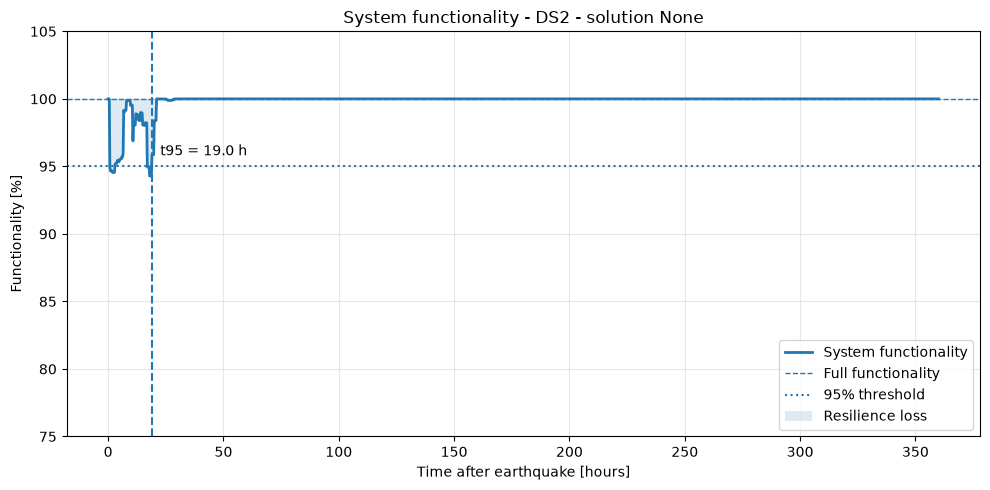

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'System functionality - DS2 - solution None'}, xlabel='Time after earthquake [hours]', ylabel='Functionality [%]'>)

In [145]:
visuals.plot_functionality(
    functionality_series=functionality_series,
    t95=t95,
    scenario_name=ds_sel
)

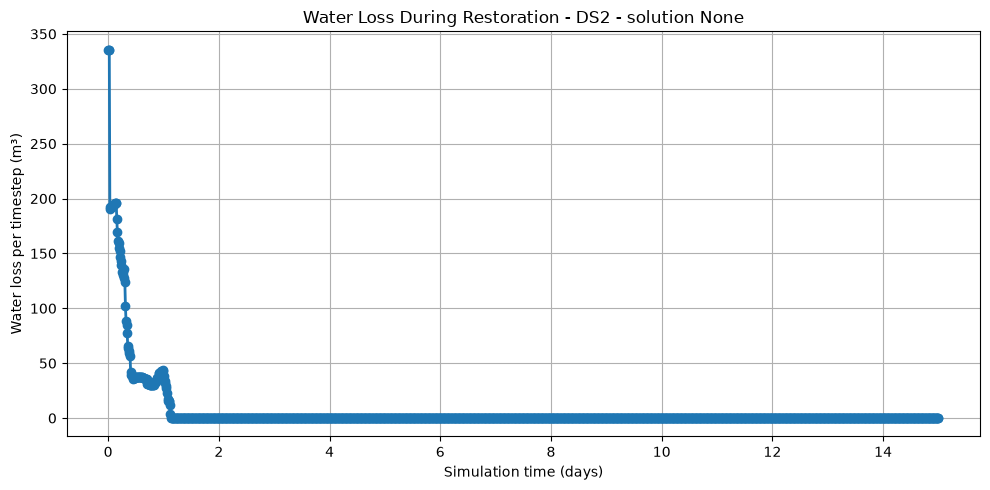

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Water Loss During Restoration - DS2 - solution None'}, xlabel='Simulation time (days)', ylabel='Water loss per timestep (m³)'>)

In [146]:
visuals.plot_water_loss(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"],
    scenario_name=ds_sel,
#    duration_days=7
)